In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re

# --- CSVをすべて読み込み ---
# 例: results_noise0.0025.csv のようなファイルをまとめて取得
csv_files = glob.glob("/work/robomimic/csv/lift/noise*.csv")

def extract_noise(filename):
    """
    ファイル名から noise の値を抽出する
    noise0.001.csv, noise0.001..csv なども安全に処理する
    """
    match = re.search(r"noise([0-9.]+)", filename)
    if match:
        value = match.group(1).rstrip('.')   # ← 末尾のドットを除去
        return float(value)
    return None

df_list = []

for file in csv_files:
    noise = extract_noise(file)
    if noise is None:
        continue
    
    df = pd.read_csv(file)
    df["noise"] = noise  # ノイズ列を追加
    df_list.append(df)

# --- 全部結合 ---
df_all = pd.concat(df_list, ignore_index=True)

# --- seed を取り除いた base_model を抽出 ---
def extract_base_model(name: str):
    match = re.match(r"(.*)_seed\d+", name)
    return match.group(1) if match else name

df_all["base_model"] = df_all["name"].apply(extract_base_model)

# --- base_model × noise ごとの success_rate 平均を計算 ---
df_avg = (
    df_all.groupby(["base_model", "noise"])["success_rate"]
           .mean()
           .reset_index()
)

print(df_avg)

       base_model   noise  success_rate
0              bc  0.0010      0.976667
1              bc  0.0025      0.970000
2              bc  0.0050      0.963333
3              bc  0.0100      0.960000
4              bc  0.0250      0.890000
5              bc  0.0500      0.630000
6          bc-rnn  0.0010      0.993333
7          bc-rnn  0.0025      0.996667
8          bc-rnn  0.0050      0.993333
9          bc-rnn  0.0100      0.986667
10         bc-rnn  0.0250      0.966667
11         bc-rnn  0.0500      0.800000
12  ncp-pure_u128  0.0010      0.960000
13  ncp-pure_u128  0.0025      0.960000
14  ncp-pure_u128  0.0050      0.786667
15  ncp-pure_u128  0.0100      0.390000
16  ncp-pure_u128  0.0250      0.050000
17  ncp-pure_u128  0.0500      0.000000
18  ncp-pure_u256  0.0010      0.986667
19  ncp-pure_u256  0.0025      0.963333
20  ncp-pure_u256  0.0050      0.896667
21  ncp-pure_u256  0.0100      0.560000
22  ncp-pure_u256  0.0250      0.136667
23  ncp-pure_u256  0.0500      0.063333


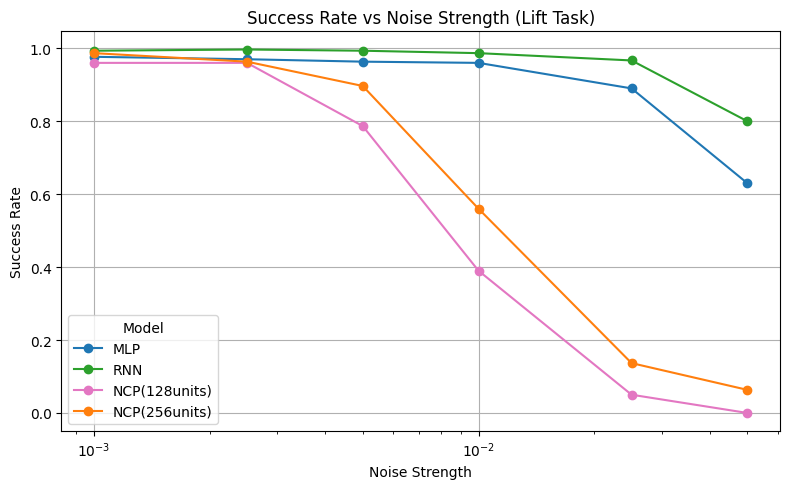

In [10]:
# --- カスタムカラーパレットと表示名を定義 ---
custom_colors = {
    "bc": "#1f77b4",      # 青
    "bc-rnn": "#2ca02c",  # 緑
    "ncp-pure_u128": "#e377c2",     # ピンク
    "ncp-pure_u256": "#ff7f0e",     # オレンジ
    "ncp-pure_u512": "#d62728",     # 赤
}
model_display_names = {
    "bc": "MLP",
    "bc-rnn": "RNN",
    "ncp-pure_u128": "NCP(128units)",
    "ncp-pure_u256": "NCP(256units)",
    "ncp-pure_u512": "NCP(512units)",
}

plt.figure(figsize=(8, 5))

for model in df_avg["base_model"].unique():
    df_m = df_avg[df_avg["base_model"] == model]
    color = custom_colors.get(model, "#7f7f7f")  # 未定義はグレー
    display_name = model_display_names.get(model, model)
    plt.plot(df_m["noise"], df_m["success_rate"], marker="o", label=display_name, color=color)

plt.xlabel("Noise Strength")
plt.ylabel("Success Rate")
plt.xscale("log")
plt.title("Success Rate vs Noise Strength (Lift Task)")
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()